# HM4, Clustering and PCA

In [26]:
import sys
import os
import importlib
import numpy as np

#Add code paths
sys.path.append(os.path.abspath("../code/part2/"))

## Load Data Set

In [27]:
import matplotlib.pyplot as plt
from sklearn import metrics, datasets, tree
from sklearn.model_selection import train_test_split

# 1. load 
data = datasets.load_breast_cancer()
X,y= data.data, data.target


## PCA

In [28]:
from sklearn.decomposition import PCA

# learn the transformation (components as linear combination of features)
pca = PCA(n_components=2)
X_pca = pca.fit(X).transform(X)
print("Components:\n",pca.components_)


Components:
 [[ 5.08623202e-03  2.19657026e-03  3.50763298e-02  5.16826469e-01
   4.23694535e-06  4.05260047e-05  8.19399539e-05  4.77807775e-05
   7.07804332e-06 -2.62155251e-06  3.13742507e-04 -6.50984008e-05
   2.23634150e-03  5.57271669e-02 -8.05646029e-07  5.51918197e-06
   8.87094462e-06  3.27915009e-06 -1.24101836e-06 -8.54530832e-08
   7.15473257e-03  3.06736622e-03  4.94576447e-02  8.52063392e-01
   6.42005481e-06  1.01275937e-04  1.68928625e-04  7.36658178e-05
   1.78986262e-05  1.61356159e-06]
 [ 9.28705650e-03 -2.88160658e-03  6.27480827e-02  8.51823720e-01
  -1.48194356e-05 -2.68862249e-06  7.51419574e-05  4.63501038e-05
  -2.52430431e-05 -1.61197148e-05 -5.38692831e-05  3.48370414e-04
   8.19640791e-04  7.51112451e-03  1.49438131e-06  1.27357957e-05
   2.86921009e-05  9.36007477e-06  1.22647432e-05  2.89683790e-07
  -5.68673345e-04 -1.32152605e-02 -1.85961117e-04 -5.19742358e-01
  -7.68565692e-05 -2.56104144e-04 -1.75471479e-04 -3.05051743e-05
  -1.57042845e-04 -5.5307166

## k Means

In [29]:
import k_means as km
importlib.reload(km) 

labels = km.do_kmeans_pca(X, pca, n_clusters=2, print_stuff = False)

In [30]:
# compute silhouette
print("Silhouette:",metrics.silhouette_score(X_pca, labels, metric='euclidean'))

Silhouette: 0.6984195775999954


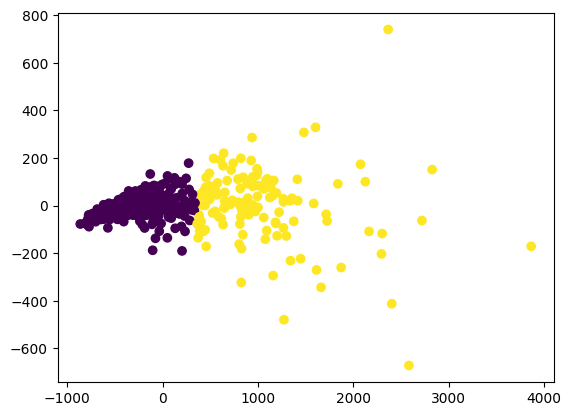

In [31]:

plt.scatter(X_pca[:,0], X_pca[:,1],c=labels)
plt.show()


## EM Clustering

In [32]:
import em_clustering as em
importlib.reload(em) 

labels_em = em.do_em_pca(X, pca, n_components = 2)

In [33]:
# compute silhouette
print("Silhouette:",metrics.silhouette_score(X_pca, labels_em, metric='euclidean'))

Silhouette: 0.5865823748565953


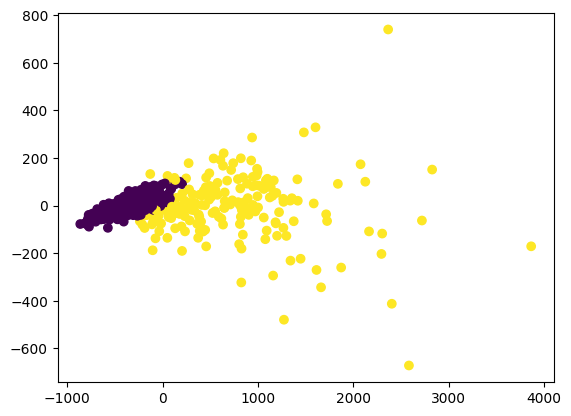

In [34]:
plt.scatter(X_pca[:,0], X_pca[:,1],c=labels_em)
plt.show()